# Support Vector Regression (ε-SVR) — BMWP Prediction

ε-SVR with an RBF kernel for prediction of the BMWP/Col water quality index in the
Cali River, Colombia, evaluated with **nested leave-one-out cross-validation**
(predictor selection and hyperparameter tuning performed inside each fold).

## 1. Introduction

This notebook implements Support Vector Regression (ε-SVR) with an RBF
kernel for prediction of the BMWP/Col water quality index in the Cali
River, Colombia. SVR was selected as a third comparative technique for
BMWP prediction because:

1. It captures non-linear relationships between physicochemical predictors
   and the BMWP index without requiring large sample sizes
2. It has been applied in directly comparable contexts: Álvarez-Álvarez
   et al. (2026) used ε-SVR with LOOCV for water quality modelling in the
   Jipijapa River (Ecuador, n=27, BMWP/Col index)
3. It complements the existing fuzzy logic (Approach E) and negative
   binomial regression models by providing a kernel-based non-parametric
   alternative

Model evaluation uses **nested LOOCV**: predictor selection by AIC is
performed inside each fold on n-1 training observations, ensuring that
no information from the held-out station leaks into either predictor
selection or model fitting. Hyperparameters (C, epsilon, gamma) are tuned
by grid search with an inner leave-one-out loop on the training fold only.

## 2. Dependencies and Data Loading

The BMWP dataset (n = 18, no outlier removal) provides the physicochemical
predictors and the continuous `BMWP` index per sampling station.

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support,
                             mean_absolute_error, r2_score)
from scipy.stats import spearmanr
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load the BMWP dataset in full (relative path, no outlier removal)
df = pd.read_excel("../../data/Database - BMWP.xlsx")
df.columns = df.columns.str.strip()
station_col = 'Estación' if 'Estación' in df.columns else df.columns[0]
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print()
print("BMWP descriptive statistics:")
print(df['BMWP'].describe().round(2))

Shape: (18, 24)
Columns: ['Estación', 'COT', 'DBO5', 'DBOu', 'DBO5s', 'DQO', 'Dureza', 'Fósforo', 'Fosfatos', 'Hierro', 'Magnesio', 'Nitritos', 'SDT', 'SST', 'Turbiedad', 'pH', 'Conductividad', 'OD', 'Temperatura', 'Coliformes', 'Profundidad', 'Velocidad', 'Caudal', 'BMWP']

BMWP descriptive statistics:
count     18.00
mean      60.06
std       32.07
min        9.00
25%       35.50
50%       60.50
75%       88.75
max      116.00
Name: BMWP, dtype: float64


In [3]:
# BMWP/Col quality classes (English) and the categorisation function (Roldán thresholds)
bmwp_classes_dict = {
    'Very critical': (0, 15),
    'Critical': (16, 35),
    'Doubtful': (36, 60),
    'Acceptable': (61, 100),
    'Good': (101, 120),
}
labels = list(bmwp_classes_dict.keys())   # worst -> best

def classify_bmwp(value):
    # Map a continuous BMWP value to its quality class label (None if out of range)
    for label, (lo, hi) in bmwp_classes_dict.items():
        if lo <= value <= hi:
            return label
    return None

# Class distribution of the observed BMWP across the five quality categories
df['BMWP_class'] = df['BMWP'].apply(classify_bmwp)
print("Observed BMWP/Col class distribution:")
print(df['BMWP_class'].value_counts().reindex(labels, fill_value=0))

Observed BMWP/Col class distribution:
BMWP_class
Very critical    2
Critical         3
Doubtful         4
Acceptable       8
Good             1
Name: count, dtype: int64


## 3. Predictor Selection (Nested)

To keep the predictor-selection criterion identical to the negative binomial
model (Notebook 04) and thus comparable, SVR uses **AIC-based nested selection**
driven by a NegativeBinomial GLM over the same seven candidate physicochemical
predictors. Exhaustive subset selection over all 22 columns is computationally
infeasible and statistically meaningless at n = 18, so the established candidate
set is used. Selection is re-run inside every fold on the n-1 training rows;
here it is also run once on the full dataset for reference only.

In [4]:
# Candidate predictors (same set as the negative binomial model, for comparability)
candidate_predictors = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']

def select_nbr_predictors(train_df, candidates, response):
    # Exhaustive AIC subset selection (NegativeBinomial GLM) on training data only
    best_aic, best_combo = np.inf, None
    for L in range(1, len(candidates) + 1):
        for subset in combinations(candidates, L):
            X_tr = sm.add_constant(train_df[list(subset)], has_constant='add')
            y_tr = train_df[response]
            try:
                result = sm.GLM(y_tr, X_tr, family=sm.families.NegativeBinomial()).fit()
                if result.aic < best_aic:
                    best_aic, best_combo = result.aic, subset
            except Exception:
                continue
    return list(best_combo)

# Full-dataset reference selection (NOT used for evaluation — reference only)
full_selection = select_nbr_predictors(df, candidate_predictors, 'BMWP')
print("Full-dataset reference selection (AIC):", full_selection)

Full-dataset reference selection (AIC): ['Dureza']


## 4. Model Definition

The SVR model is a `StandardScaler` + RBF-kernel `SVR` pipeline. Standardisation is
essential for SVR; placing it inside the pipeline ensures it is refitted on training
data only within each (inner and outer) fold. Hyperparameters are tuned by grid
search.

In [5]:
# SVR pipeline (scaler + RBF SVR) and the hyperparameter grid tuned inside each fold
def build_svr_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf'))
    ])

param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.1, 0.5, 1.0, 2.0],
    'svr__gamma': ['scale', 'auto'],
}
print("Pipeline:", build_svr_pipeline())
print("Grid size:", len(param_grid['svr__C']) * len(param_grid['svr__epsilon']) * len(param_grid['svr__gamma']),
      "combinations")

Pipeline: Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR())])
Grid size: 32 combinations


## 5. Calibration

In the LOOCV framework each fold trains on n-1 observations and evaluates on one
held-out station. A single nested-LOOCV pass below produces both the **validation**
(held-out) predictions and the **calibration** (training-fold) predictions. For each
fold the predictors are selected by nested AIC, the SVR hyperparameters are tuned by
GridSearchCV with an inner leave-one-out loop on the training rows only, and the best
estimator is refitted on the full training fold.

Calibration metrics aggregate the training-fold predictions across all folds and
reflect **near-in-sample** performance; the validation metrics in Section 6 are the
primary evidence.

In [6]:
# Single nested-LOOCV pass: collect validation + calibration predictions, selections, hyperparameters
loo = LeaveOneOut()
y_true_val, y_pred_val_crisp = [], []
y_true_cal, y_pred_cal_crisp = [], []
selected_predictors_per_fold, best_params_per_fold = [], []

X_full = df[candidate_predictors].values
for fold, (train_idx, test_idx) in enumerate(loo.split(X_full)):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # Step 1: nested predictor selection on training data only
    selected = select_nbr_predictors(df_train, candidate_predictors, 'BMWP')
    selected_predictors_per_fold.append(selected)

    X_train = df_train[selected].values
    X_test = df_test[selected].values
    y_train = df_train['BMWP'].values
    y_test = df_test['BMWP'].values

    # Step 2: hyperparameter tuning on training data only (inner leave-one-out)
    inner_cv = LeaveOneOut()
    grid = GridSearchCV(build_svr_pipeline(), param_grid, cv=inner_cv,
                        scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_params_per_fold.append(grid.best_params_)
    best_model = grid.best_estimator_

    # Step 3: validation prediction (held-out station)
    y_pred_val_crisp.append(float(best_model.predict(X_test)[0]))
    y_true_val.append(float(y_test[0]))

    # Step 4: calibration predictions (training rows of this fold)
    y_pred_cal_crisp.extend(best_model.predict(X_train).tolist())
    y_true_cal.extend(y_train.tolist())

print("Nested LOOCV complete:", len(y_true_val), "validation folds,",
      len(y_true_cal), "accumulated calibration predictions.")

Nested LOOCV complete: 18 validation folds, 306 accumulated calibration predictions.


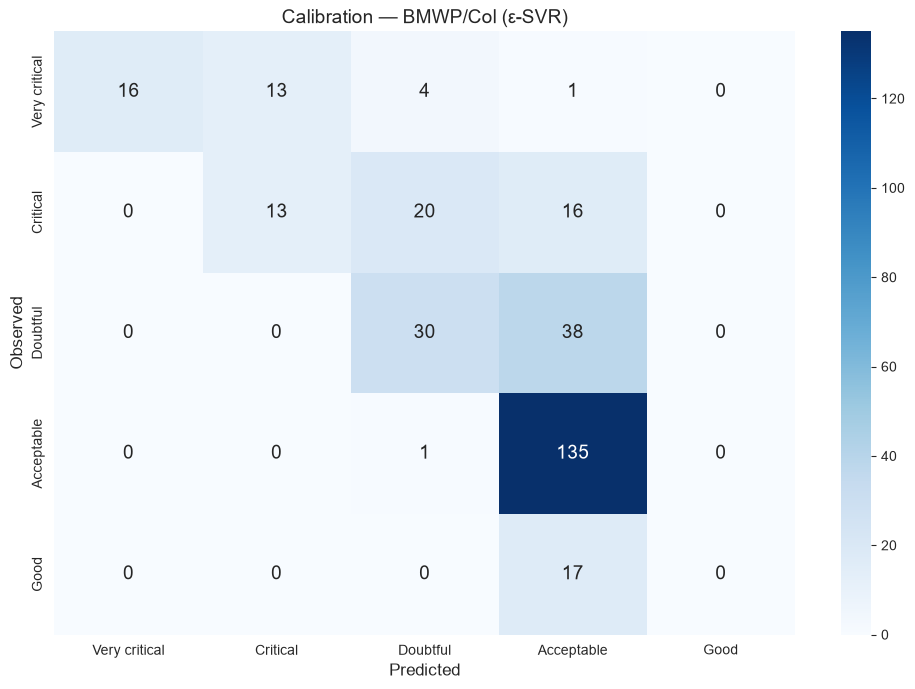

               precision    recall  f1-score   support

Very critical       1.00      0.47      0.64        34
     Critical       0.50      0.27      0.35        49
     Doubtful       0.55      0.44      0.49        68
   Acceptable       0.65      0.99      0.79       136
         Good       0.00      0.00      0.00        17

     accuracy                           0.64       304
    macro avg       0.54      0.43      0.45       304
 weighted avg       0.61      0.64      0.59       304

Cohen's Kappa (calibration): 0.430
Calibration numerical: MAE = 15.35, RMSE = 22.80, R² = 0.465, rs = 0.675
Note: calibration reflects near-in-sample performance; Section 6 (validation) is the primary evidence.


In [7]:
# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

# Map calibration predictions to classes (drop any out-of-range) and report calibration metrics
def to_classes(true_vals, pred_vals):
    tc = [classify_bmwp(v) for v in true_vals]
    pc = [classify_bmwp(v) for v in pred_vals]
    idx = [i for i, (t, p) in enumerate(zip(tc, pc)) if t is not None and p is not None]
    return [tc[i] for i in idx], [pc[i] for i in idx]

cal_true_class, cal_pred_class = to_classes(y_true_cal, y_pred_cal_crisp)
plot_confusion(cal_true_class, cal_pred_class, 'Calibration — BMWP/Col (ε-SVR)',
               'svr_bmwp_confusion_matrix_calibration.png')
print(classification_report(cal_true_class, cal_pred_class, labels=labels, zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(cal_true_class, cal_pred_class):.3f}")

cal_obs = np.array(y_true_cal); cal_hat = np.array(y_pred_cal_crisp)
print(f"Calibration numerical: MAE = {mean_absolute_error(cal_obs, cal_hat):.2f}, "
      f"RMSE = {np.sqrt(np.mean((cal_obs - cal_hat) ** 2)):.2f}, R² = {r2_score(cal_obs, cal_hat):.3f}, "
      f"rs = {spearmanr(cal_obs, cal_hat)[0]:.3f}")
print("Note: calibration reflects near-in-sample performance; Section 6 (validation) is the primary evidence.")

## 6. Validation (Nested LOOCV)

The honest out-of-sample estimate: each metric below is computed on the held-out
stations only, where predictor selection, hyperparameter tuning and model fitting all
excluded that station.

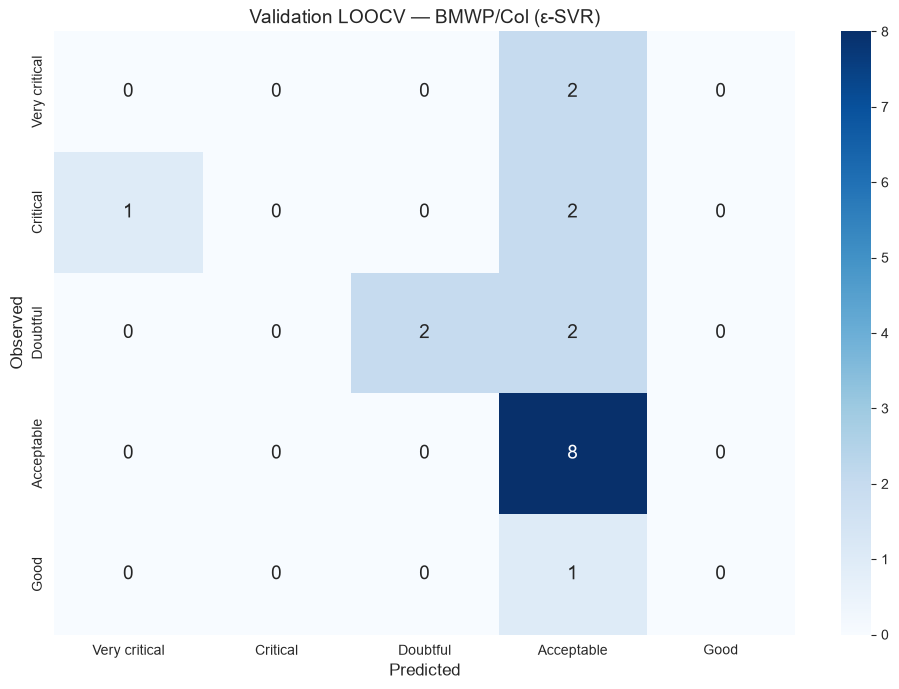

               precision    recall  f1-score   support

Very critical       0.00      0.00      0.00         2
     Critical       0.00      0.00      0.00         3
     Doubtful       1.00      0.50      0.67         4
   Acceptable       0.53      1.00      0.70         8
         Good       0.00      0.00      0.00         1

     accuracy                           0.56        18
    macro avg       0.31      0.30      0.27        18
 weighted avg       0.46      0.56      0.46        18

Cohen's Kappa (validation): 0.258


In [8]:
# Validation: map held-out predictions to classes, confusion matrix, classification report, kappa
val_true_class, val_pred_class = to_classes(y_true_val, y_pred_val_crisp)
plot_confusion(val_true_class, val_pred_class, 'Validation LOOCV — BMWP/Col (ε-SVR)',
               'svr_bmwp_confusion_matrix_validation.png')
print(classification_report(val_true_class, val_pred_class, labels=labels, zero_division=0))
kappa_svr = cohen_kappa_score(val_true_class, val_pred_class)
print(f"Cohen's Kappa (validation): {kappa_svr:.3f}")

In [9]:
# Regression metrics on the continuous held-out predictions
val_obs = np.array(y_true_val, dtype=float)
val_hat = np.array(y_pred_val_crisp, dtype=float)
mae_svr = mean_absolute_error(val_obs, val_hat)
rmse_svr = float(np.sqrt(np.mean((val_obs - val_hat) ** 2)))
r2_svr = r2_score(val_obs, val_hat)
rs_svr, p_svr = spearmanr(val_obs, val_hat)
print(f"MAE:  {mae_svr:.2f} BMWP points")
print(f"RMSE: {rmse_svr:.2f} BMWP points")
print(f"R²:   {r2_svr:.3f}")
print(f"Spearman rs: {rs_svr:.3f} (p = {p_svr:.4f})")

MAE:  23.71 BMWP points
RMSE: 31.60 BMWP points
R²:   -0.028
Spearman rs: 0.430 (p = 0.0746)


In [10]:
# Model diagnostics: predictor stability and best hyperparameters per fold
stab = pd.DataFrame({'Fold': range(1, len(selected_predictors_per_fold) + 1),
                     'Selected predictors': ['+'.join(s) for s in selected_predictors_per_fold],
                     'C': [bp['svr__C'] for bp in best_params_per_fold],
                     'epsilon': [bp['svr__epsilon'] for bp in best_params_per_fold],
                     'gamma': [bp['svr__gamma'] for bp in best_params_per_fold]})
display(stab)

# Predictor selection frequency across folds
pred_freq = Counter(p for s in selected_predictors_per_fold for p in s)
pred_freq = {p: pred_freq.get(p, 0) for p in candidate_predictors}
modal_set = Counter(tuple(sorted(s)) for s in selected_predictors_per_fold).most_common(1)[0]
print("Predictor selection frequency (folds containing each predictor):", pred_freq)
print(f"Modal predictor set: {modal_set[0]} selected in {modal_set[1]}/{len(selected_predictors_per_fold)} folds")

# Most common hyperparameter combination
hp_counts = Counter((bp['svr__C'], bp['svr__epsilon'], bp['svr__gamma']) for bp in best_params_per_fold)
print("Most common (C, epsilon, gamma) combinations:", hp_counts.most_common(3))

# Persist fold-level diagnostics
stab.to_csv("../../outputs/svr_bmwp_fold_details.csv", index=False)
print("Saved outputs/svr_bmwp_fold_details.csv")

,Fold,Selected predictors,C,epsilon,gamma
0,1,Dureza,100,1.0,scale
1,2,Dureza,100,1.0,scale
2,3,Turbiedad,10,2.0,scale
3,4,Dureza,100,1.0,scale
4,5,Dureza,100,2.0,auto
5,6,Dureza,100,1.0,scale
6,7,Dureza,100,2.0,scale
7,8,Dureza,100,1.0,scale
8,9,Dureza,100,1.0,scale
9,10,Magnesio,100,0.1,scale


Predictor selection frequency (folds containing each predictor): {'COT': 0, 'DBO5': 0, 'Dureza': 14, 'Magnesio': 1, 'Turbiedad': 3, 'OD': 0, 'Caudal': 0}
Modal predictor set: ('Dureza',) selected in 14/18 folds
Most common (C, epsilon, gamma) combinations: [((100, 1.0, 'scale'), 8), ((100, 0.1, 'scale'), 3), ((10, 2.0, 'scale'), 2)]
Saved outputs/svr_bmwp_fold_details.csv


## 7. Numerical Performance Summary

In [11]:
# Numerical performance summary and comparison with the other BMWP models (nested LOOCV)
print(f"=== SVR BMWP Numerical Performance (Nested LOOCV, n={len(val_obs)}) ===")
print(f"MAE:  {mae_svr:.2f} BMWP points")
print(f"RMSE: {rmse_svr:.2f} BMWP points")
print(f"R²:   {r2_svr:.3f}")
print(f"Spearman rs: {rs_svr:.3f} (p = {p_svr:.4f})")
print(f"Cohen's Kappa: {kappa_svr:.3f}")
print()
print(f"Interpretation: on average, the SVR model's BMWP predictions deviate")
print(f"by {mae_svr:.2f} points from the observed values on the BMWP/Col scale (0-120).")
print()

# Reference values (nested LOOCV) from the fuzzy redesigned and NBR notebooks
fuzzy_mae, fuzzy_r2, fuzzy_rs, fuzzy_kappa = 26.77, 0.07, 0.281, 0.163
nbr_mae, nbr_r2, nbr_rs, nbr_kappa = 31.95, -0.27, -0.162, 0.000

def verdict(svr, fuzzy, nbr, higher_is_better=True):
    if higher_is_better:
        best = max(svr, fuzzy, nbr)
    else:
        best = min(svr, fuzzy, nbr)
    return "outperforms" if svr == best else ("matches" if abs(svr - best) < 1e-9 else "underperforms")

print(f"Compared with fuzzy logic redesigned (nested: MAE={fuzzy_mae}, R²={fuzzy_r2}, kappa={fuzzy_kappa})")
print(f"and negative binomial regression (nested: MAE={nbr_mae}, R²={nbr_r2}, kappa={nbr_kappa}):")
print(f"  - MAE: SVR {verdict(mae_svr, fuzzy_mae, nbr_mae, higher_is_better=False)} (lower is better)")
print(f"  - R²:  SVR {verdict(r2_svr, fuzzy_r2, nbr_r2)}")
print(f"  - Spearman rs: SVR {verdict(rs_svr, fuzzy_rs, nbr_rs)}")
print(f"  - Kappa: SVR {verdict(kappa_svr, fuzzy_kappa, nbr_kappa)}")

# Export class-level and numerical metrics for the master results table
present = [c for c in labels if c in val_true_class]
prec, rec, f1m, _ = precision_recall_fscore_support(val_true_class, val_pred_class, labels=present,
                                                    average='macro', zero_division=0)
acc_svr = accuracy_score(val_true_class, val_pred_class)
pd.DataFrame([{'target': 'BMWP', 'technique': 'ε-SVR', 'validation': 'Nested LOOCV', 'n': len(val_obs),
               'precision': round(prec, 3), 'recall': round(rec, 3), 'f1': round(f1m, 3),
               'accuracy': round(acc_svr, 3), 'kappa': round(kappa_svr, 3),
               'modal_predictors': '+'.join(modal_set[0]),
               'predictor_stability': f"{modal_set[1]}/{len(selected_predictors_per_fold)}"}]
             ).to_csv("../../outputs/metrics_svr_bmwp.csv", index=False)
pd.DataFrame([{'model': 'ε-SVR', 'validation': 'Nested LOOCV', 'n': len(val_obs),
               'mae': round(mae_svr, 2), 'rmse': round(rmse_svr, 2), 'r2': round(r2_svr, 3),
               'rs': round(rs_svr, 3), 'p_value': round(p_svr, 4)}]
             ).to_csv("../../outputs/numerical_bmwp_svr.csv", index=False)
print()
print("Saved outputs/metrics_svr_bmwp.csv and outputs/numerical_bmwp_svr.csv")

=== SVR BMWP Numerical Performance (Nested LOOCV, n=18) ===
MAE:  23.71 BMWP points
RMSE: 31.60 BMWP points
R²:   -0.028
Spearman rs: 0.430 (p = 0.0746)
Cohen's Kappa: 0.258

Interpretation: on average, the SVR model's BMWP predictions deviate
by 23.71 points from the observed values on the BMWP/Col scale (0-120).

Compared with fuzzy logic redesigned (nested: MAE=26.77, R²=0.07, kappa=0.163)
and negative binomial regression (nested: MAE=31.95, R²=-0.27, kappa=0.0):
  - MAE: SVR outperforms (lower is better)
  - R²:  SVR underperforms
  - Spearman rs: SVR outperforms
  - Kappa: SVR outperforms

Saved outputs/metrics_svr_bmwp.csv and outputs/numerical_bmwp_svr.csv


## 8. Visualisation

Three diagnostics are produced and saved to `outputs/`: observed vs predicted BMWP,
predictor selection frequency across folds, and the distribution of tuned
hyperparameters across folds.

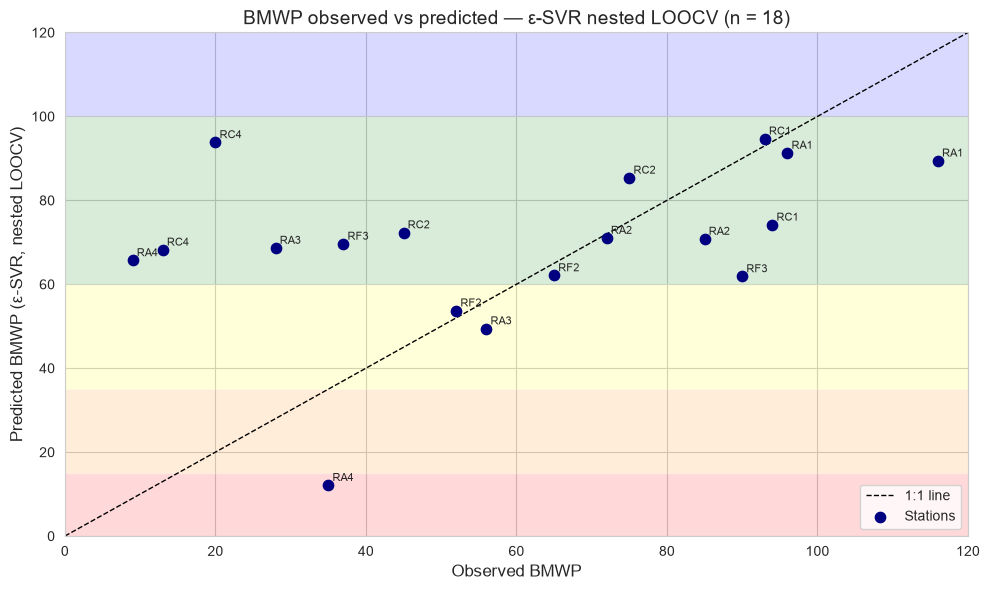

In [12]:
# Plot 1: observed vs predicted BMWP (nested LOOCV) with 1:1 line and quality-band backgrounds
stations = [df.iloc[i][station_col] for i in range(len(df))]
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]
plt.figure(figsize=(10, 6))
for lo, hi, col in bands:
    plt.axhspan(lo, hi, facecolor=col, alpha=0.15)
plt.plot([0, 120], [0, 120], 'k--', linewidth=1, label='1:1 line')
plt.scatter(val_obs, val_hat, color='navy', s=55, zorder=3, label='Stations')
for x, y, lab in zip(val_obs, val_hat, stations):
    plt.annotate(str(lab), (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')
plt.xlim(0, 120); plt.ylim(0, 120)
plt.xlabel('Observed BMWP', fontsize=12)
plt.ylabel('Predicted BMWP (ε-SVR, nested LOOCV)', fontsize=12)
plt.title(f'BMWP observed vs predicted — ε-SVR nested LOOCV (n = {len(val_obs)})', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig("../../outputs/svr_bmwp_observed_vs_predicted.png", dpi=300); plt.show()

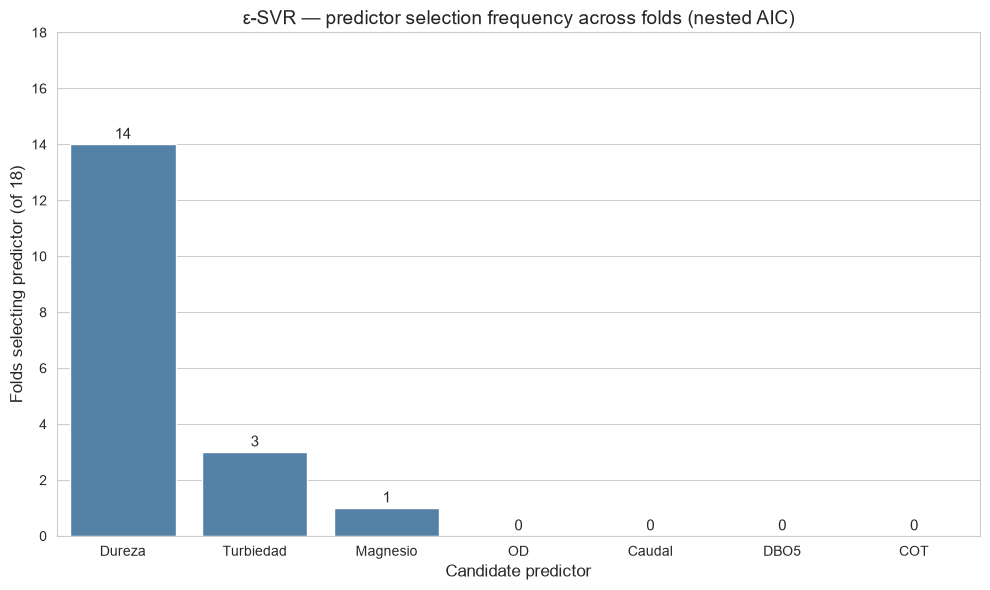

In [13]:
# Plot 2: predictor selection frequency across the 18 folds
plt.figure(figsize=(10, 6))
preds = list(pred_freq.keys()); freqs = [pred_freq[p] for p in preds]
order = np.argsort(freqs)[::-1]
preds = [preds[i] for i in order]; freqs = [freqs[i] for i in order]
sns.barplot(x=preds, y=freqs, color='steelblue')
plt.ylabel('Folds selecting predictor (of 18)', fontsize=12); plt.xlabel('Candidate predictor', fontsize=12)
plt.title('ε-SVR — predictor selection frequency across folds (nested AIC)', fontsize=14)
plt.ylim(0, 18)
for i, v in enumerate(freqs):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=11)
plt.tight_layout(); plt.savefig("../../outputs/svr_bmwp_predictor_frequency.png", dpi=300); plt.show()

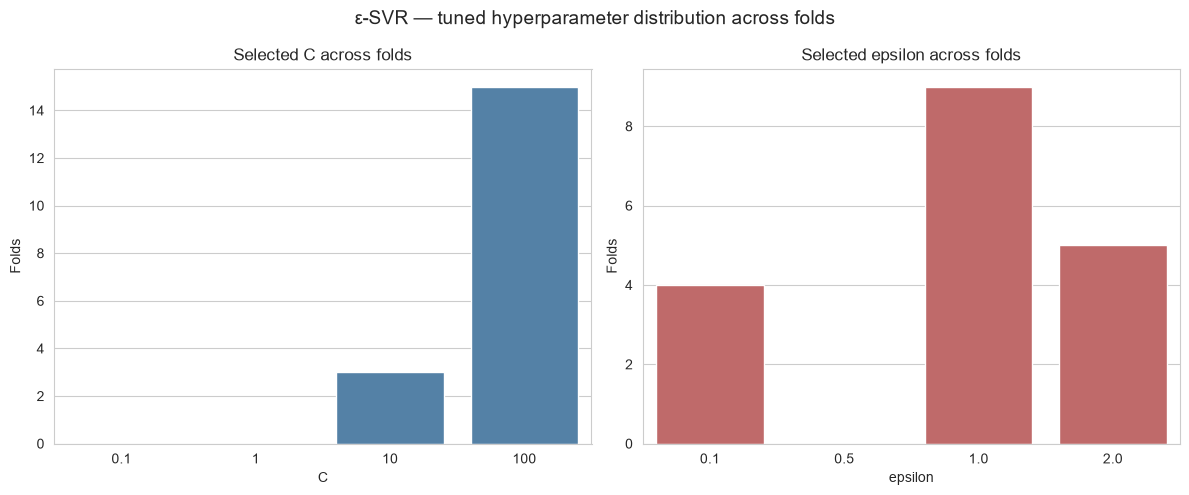

In [14]:
# Plot 3: distribution of tuned hyperparameters (C and epsilon) across folds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
C_vals = [bp['svr__C'] for bp in best_params_per_fold]
eps_vals = [bp['svr__epsilon'] for bp in best_params_per_fold]
sns.countplot(x=[str(c) for c in C_vals], order=[str(c) for c in param_grid['svr__C']],
              color='steelblue', ax=axes[0])
axes[0].set_title('Selected C across folds'); axes[0].set_xlabel('C'); axes[0].set_ylabel('Folds')
sns.countplot(x=[str(e) for e in eps_vals], order=[str(e) for e in param_grid['svr__epsilon']],
              color='indianred', ax=axes[1])
axes[1].set_title('Selected epsilon across folds'); axes[1].set_xlabel('epsilon'); axes[1].set_ylabel('Folds')
fig.suptitle('ε-SVR — tuned hyperparameter distribution across folds', fontsize=14)
plt.tight_layout(); plt.savefig("../../outputs/svr_bmwp_hyperparameters.png", dpi=300); plt.show()

## 9. Limitations

- SVR requires hyperparameter tuning (C, epsilon, gamma); with n=17
  training observations per fold and inner LOOCV for tuning, the grid
  search uses n=16 for each inner fold — a very small training set that
  may produce unstable hyperparameter estimates.
- The RBF kernel implicitly assumes smooth, continuous relationships
  between predictors and BMWP; if the true relationship has sharp
  ecological thresholds, a linear kernel may be more appropriate.
- Predictor selection by AIC (NBR-based) may not be optimal for SVR;
  AIC is derived from likelihood theory and is not directly applicable
  to kernel methods. The consistency of predictor selection across folds
  should be interpreted as a robustness check, not a formal criterion.
- With n=18 and 5 BMWP quality classes, some classes may have 0 or 1
  observations in certain training folds, which can cause classification
  metrics to be undefined or unstable.